# Comparison to Israel Building Dataset (2022), mapped by the Survey of Israel
**Author:** Eliya Levin

**Contact details:** please mail questions to eliya.levin@mail.huji.ac.il

**Last update:** 12/05/2026

## Setup

### Libraries

In [1]:
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import time
from IPython.display import Markdown
from shapely import wkb
import glob
import sys
import importlib

### Path

In [2]:
current_dir = os.getcwd() # directory path of the notebook
main_dir = os.path.abspath(os.path.join(current_dir, "..")) # parent directory path of the notebook

In [3]:
data_path = r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\Data'

### Link function notebook

In [4]:
# Adding path to system
sys.path.append(main_dir)

In [5]:
# Importing relevant functions
from functions import get_len, get_count, get_area, get_density # API call requests

### Add post functions

In [6]:
# API count building number by geometry
def post_count(geom, filter="type:way and building=*", time="2008-01-01/2025-01-01/P1M", path=None, filename=None):
    '''
    A function that extracts cummulative number of buildings (building tags) in a specific geometry from OSM using the Ohsome API, and returns all data in a json format.

    The function recieves 3 strings:
        1) **geom** - simplified geometry parameter
        2) **filter** - filter parameter, defaultly extracting all building tags from way objects
        3) **time** - ISO-8621 timestamp. Defaultly extracting all data between 01/2008-01/2025 in monthly intervals
    
    If the user wants to save the data, there are two additional parameters:
        1) **path** - string to path on computer
        2) **filename** - string with requested filename

    Dependencies:
    * requests
    * json
    * os
    * pandas as pd
    '''
    # Ensuring needed libraries are imported
    import requests
    import json
    import os
    import pandas as pd

    url = "https://api.ohsome.org/v1/elements/count/groupBy/boundary" # URL for API

    # Defining parameters for extract
    params = {
        "bpolys": json.dumps({
            "type": "FeatureCollection",
            "features": [{
                "type": "Feature",
                "properties": {"id": "region"},
                "geometry": geom
            }]
        }),
        "filter": filter,
        "time": time,
        "format": "json"
    }


    response = requests.post(url, data=params) # Creating request

    if response.status_code == 200:
        print("Succesfully extracted counts")
        data = response.json() # data extract

        # Saving extract to file if requested:
        if path and filename:
            os.makedirs(path, exist_ok=True)  # create directory if it doesn't exist
            file_path = os.path.join(path, filename)
            with open(file_path, 'w', encoding='utf-8') as f:
                json.dump(data, f, ensure_ascii=False, indent=2)
            print(f"Data saved to {file_path}")

        return pd.json_normalize(data['groupByResult'][0]['result'])
    
    # Print errors if recieved for debugging 
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None

In [7]:
# API post bulding area function by geometry
def post_area(geom, filter="type:way and building=*", time="2008-01-01/2025-01-01/P1M", path=None, filename=None):
    '''
    A function that extracts aggregated area of buildings (highway tags) in a specific geometry from OSM using the Ohsome API, and returns all data in a json format.

    The function recieves 3 strings:
        1) **geom** - simplified geometry parameter
        2) **filter** - filter parameter, defaultly extracting all highway tags from way objects
        3) **time** - ISO-8621 timestamp. Defaultly extracting all data between 01/2008-01/2025 in monthly intervals
    
    If the user wants to save the data, there are two additional parameters:
        1) **path** - string to path on computer
        2) **filename** - string with requested filename
    
    Dependencies:
    * requests
    * json
    * os
    * pandas as pd
    '''
    # Ensuring needed libraries are imported
    import requests
    import json
    import os
    import pandas as pd

    url = "https://api.ohsome.org/v1/elements/area/groupBy/boundary" # URL for API

    # Defining parameters for extract
    params = {
        "bpolys": json.dumps({
            "type": "FeatureCollection",
            "features": [{
                "type": "Feature",
                "properties": {"id": "region"},
                "geometry": geom
            }]
        }),
        "filter": filter,
        "time": time,
        "format": "json"
    }
    
    response = requests.post(url, data=params) # Creating request

    if response.status_code == 200:
        print("Succesfully extracted areas")
        data = response.json() # data extract

        # Saving extract to file if requested:
        if path and filename:
            os.makedirs(path, exist_ok=True)  # create directory if it doesn't exist
            file_path = os.path.join(path, filename)
            with open(file_path, 'w', encoding='utf-8') as f:
                json.dump(data, f, ensure_ascii=False, indent=2)
            print(f"Data saved to {file_path}")

        return pd.json_normalize(data['groupByResult'][0]['result'])
    
    # Print errors if recieved for debugging 
    else:
        print(f"Error {response.status_code}: {response.text}")
        return None

In [8]:
# Assess the feature completness measure of some polygon using cumulative feature counts and lengths/areas
def assess_feature_completeness(count_gdf, size_gdf, alpha=0.1, time_thresh=2, saturation_thresh=1.5, abs_thresh=1.5, return_full=False):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative value of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added value (length / area) per each added unit.
    After that, the function applies the following statistical test:
    
    `If all cumulative change percentage is below some alpha (default: 10%) for a stable time period (default: 2 years) without a large absolute addition (default: 150% more than saturation point), the data is considered saturated.`
    
    For supposedly saturated data, the function computes the saturation point (1st month in stable period) and calculates cumulative percentage up to that point.

    The test is verified using 3 conditions:
    (1) No meaningfull relative addition (percentage<`alpha`) for at least `time_thresh` years.
    (2) No absolute addition (count<`abs_thresh`) for at least `time_thresh` years.
    (3) The absolute or relative addition change percentage since the saturation point is less than `saturation_thresh`.

    In all cases, the output is a DataFrame:
    * If not saturated --> the merged DataFrame, with updated timstamps and calculations.
    * If saturated --> can either return only values up to the saturation point + maximum value (default) or return the entire data with reference to the saturation point.
    
    Dependencies:
    * pandas as pd
    '''
    #---------------------------------------------------#
    #                   Data Wrangle                    #
    #---------------------------------------------------#

    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Merge Dataframes
    gdf = count_gdf.copy().rename(columns={'value' : 'count'}) # Copy DF and rename count column
    gdf['size'] = size_gdf['value'] # Append size column

    #---------------------------------------------------#
    #                 Statistical Test                  #
    #---------------------------------------------------#
    
    # Transform values
    gdf['cumulative_percentage'] = gdf['size'] / gdf['count']
    gdf['cumulative_percentage'] = gdf['cumulative_percentage'].fillna(0) # Deal with periods without addition
    gdf['normalized_cum_per'] = gdf['cumulative_percentage'] / gdf['cumulative_percentage'].max()

    # Adjust alpha value for small to large mapping case
    if gdf['cumulative_percentage'].idxmax() >= (len(gdf) * 0.75):
        alpha = 1 - alpha

    # Apply completeness test for level alpha
    gdf['test'] = (gdf['normalized_cum_per'] < alpha) # Boolean term for each date in data

    #---------------------------------------------------#
    #                   Condititon 1                    #
    #---------------------------------------------------#

    # Iterate backwards in data to find stability period
    i = -1 # Running index (from end)
    test = gdf['test'].iat[i] # Running boolean test answer (from end)
    while test:
        try: # Update index
            i -= 1
            test = gdf['test'].iat[i]
        
        except IndexError: # Break loop if at first index
            break
    
    if i == -1:
        # Deal with last value percentage being greater than alpha (i.e. no stable period)
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'no stable period'
            }

    stable = gdf.iloc[i+1:].copy() # Extract stable period

    ## If stable period shorter than given time threshold --> data is incomplete
    if (stable['timestamp'].max() - stable['timestamp'].min()) < pd.Timedelta(days=time_thresh*365):
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'stable period shorter than threshold'
            }
    
    #---------------------------------------------------#
    #             Condititon 3 - 1st phase              #
    #---------------------------------------------------#

    else:
        # Extract saturated value
        saturation_point = stable.iloc[0]

        # Calculate saturation levels
        gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
        
         # Extract emprical maximal value
        real_max = gdf.iloc[-1]
      

        # Check first if data converged. If not, verify if almost converged after one-time event (if exists).
        # Test condition 3 for relative change:
        if (real_max['percentage_until_saturation'] >= saturation_thresh):

    #---------------------------------------------------#
    #                   Condititon 2                    #
    #---------------------------------------------------#

            stable['count_change'] = stable['count'] / stable['count'].max() # Calculate absolute change
            if (stable['count_change'] >= abs_thresh).any():
                # There exists some one-time addition event after saturation
                abs_add_index = stable['count_change'].idxmax()
                if (stable['timestamp'].max() - stable.loc[abs_add_index, 'timestamp']) < pd.Timedelta(days=time_thresh*365):
                    # No stable period since one-time addition event 
                    print('Data incomplete: no stable absolute addition period')
    
    #---------------------------------------------------#
    #             Condititon 3 - 2nd phase              #
    #---------------------------------------------------#

                # Redefine saturation point and levels for one-time addition event
                saturation_point = stable.iloc[abs_add_index]
                gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
                real_max = gdf.iloc[-1]
                
                # Test condition 3 for absoulte change:
                if (real_max['percentage_until_saturation'] >= saturation_thresh):
                    return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable absolute addition larger than threshold'
                        }

            
            else:
                return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable relative addition larger than threshold'
                        }
    
    #---------------------------------------------------#
    #             Output Saturated Results              #
    #---------------------------------------------------#

        # Extract 80% saturation timestamp
        saturated_time = gdf[gdf['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]

        ### Return entire gdf if requested
        if return_full:
            return {
                    'result': gdf,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }
        
        ### Return compact gdf (default)
        else:
            # Filter data until saturation
            saturated = gdf.iloc[:i+1].copy()
        
            # Concatenate empirical maximal value
            saturated = pd.concat([saturated,
                                   pd.DataFrame([real_max])],
                                   ignore_index=True)       
            return {
                    'result': saturated,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }

## Upload and Extract data

In [9]:
bld22 = gpd.read_file(data_path + r'\bld22.gdb', layer='מבנים') # upload building dataset from 2022 (the most recent one)

In [10]:
# Inspect data
print('Dataset CRS:', bld22.crs)
print('Dataset columns:', bld22.columns)
print('Number of records:', len(bld22))

bld22.head(n=3)

Dataset CRS: EPSG:2039
Dataset columns: Index(['UNIQ_ID', 'PARENT', 'FCODE', 'FTYPE', 'HI_PNT_X', 'HI_PNT_Y',
       'HI_PNT_Z', 'HEIGHT', 'HT_LAND', 'FNAME', 'LATIN_NAME', 'BLDG_HT',
       'ADDR_ID', 'ADDR_COUNT', 'USG_ID', 'CMPLX_ID', 'CMLX_FCD', 'ORIG_AREA',
       'DATA_YEAR', 'PRDCT_VER', 'SHAPE_Length', 'SHAPE_Area', 'geometry'],
      dtype='object')
Number of records: 1956724


,UNIQ_ID,PARENT,FCODE,FTYPE,HI_PNT_X,HI_PNT_Y,HI_PNT_Z,HEIGHT,HT_LAND,FNAME,...,ADDR_COUNT,USG_ID,CMPLX_ID,CMLX_FCD,ORIG_AREA,DATA_YEAR,PRDCT_VER,SHAPE_Length,SHAPE_Area,geometry
0,51662488,726235.0,201,11,227987.718750,723521.8750,72.900002,66.0,61.180000,None,...,4,54004694.0,NaN,NaN,1429.872559,2018.0,2020-06,182.329270,1429.872584,"MULTIPOLYGON (((2.28e+05 7.24e+05, 2.28e+05 7...."
1,51662286,6542510.0,201,11,221995.265625,636437.4375,824.500000,820.5,801.900024,None,...,1,NaN,65762976.0,252.0,5057.721451,2017.0,2018-12,404.462663,5057.721516,"MULTIPOLYGON (((2.22e+05 6.36e+05, 2.22e+05 6...."
2,51663741,738871.0,201,11,231479.812500,726886.7500,153.300003,150.5,146.240005,None,...,1,NaN,65473924.0,252.0,2189.582077,2020.0,2020-12,267.508041,2189.582057,"MULTIPOLYGON (((2.31e+05 7.27e+05, 2.31e+05 7...."


In [11]:
# Update crs to OSM crs
bld22 = bld22.to_crs(epsg=4326)

In [12]:
# Extract bounds for bbox query
bld22_extent = bld22.total_bounds
print('Dataset extent (minx, miny, maxx, maxy):', bld22_extent)

Dataset extent (minx, miny, maxx, maxy): [34.26993989 29.49069016 35.88725634 33.32104959]


In [13]:
# Calculated bounds as string for quicker computation
bld22_bbox = '34.26993989,29.49069016,35.88725634,33.32104959'

In [14]:
# Extract convex hull due to large shoulders in extent (for post function)
# bld22_convex_hull = bld22.geometry.union_all().convex_hull

# Due to computational effort for the gdf, I'll import a convex hull calculated upon the layer using "Minimum Bounding Geometry" in ArcGIS Pro
bld22_convex_hull = gpd.read_file(r'C:\GIS\1_Work\OSM_research\sandbox\sandbox.gdb', layer='bld_convexhull')
bld22_convex_hull = bld22_convex_hull.to_crs(epsg=4326)
bld22_chull_geom = bld22_convex_hull['geometry'].iloc[0].__geo_interface__ # Convert to dictionary for the function

### Extract data using GET and bbox

In [15]:
# bld_count = get_count(bounds=bld22_bbox, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# bld_area = get_area(bounds=bld22_bbox, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")

In [16]:
# # Save to csv
# bld_count.to_csv(main_dir + r'\1) Data\3) validity\israel_bbox_bld_counts.csv')
# bld_area.to_csv(main_dir + r'\1) Data\3) validity\israel_bbox_bld_areas.csv')

In [17]:
# For quicker upload
bld_count = pd.read_csv(main_dir + r'\1) Data\3) validity\israel_bbox_bld_counts.csv')
bld_area = pd.read_csv(main_dir + r'\1) Data\3) validity\israel_bbox_bld_areas.csv')

### Extract data using POST and convex hull

In [18]:
# bld_count_ch = post_count(geom=bld22_chull_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# bld_area_ch = post_area(geom=bld22_chull_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")

In [19]:
# # Save to csv
# bld_count_ch.to_csv(main_dir + r'\1) Data\3) validity\israel_chull_bld_counts.csv')
# bld_area_ch.to_csv(main_dir + r'\1) Data\3) validity\israel_chull_bld_areas.csv')

In [20]:
# For quicker upload
bld_count_ch = pd.read_csv(main_dir + r'\1) Data\3) validity\israel_chull_bld_counts.csv')
bld_area_ch = pd.read_csv(main_dir + r'\1) Data\3) validity\israel_chull_bld_areas.csv')

## Metric calculation

### Reference Dataset

In [21]:
# # Upload calculated metrics for quicker computation
# bld22_cum_area = 547314524.7697108
# bld22_counts = 1956724
# bld22_metric = 279.7096191234486

In [22]:
# Calculate metric requirements for reference dataset
bld22_cum_area = bld22['ORIG_AREA'].sum() # sum all building areas
bld22_counts = len(bld22) # count number of buildings
bld22_metric = bld22_cum_area / bld22_counts # calculate area per building

# Print results
print('Total area of reference dataset:', bld22_cum_area)
print('Number of buildings in reference dataset:', bld22_counts)
print('Area per building in reference dataset:', bld22_metric)

Total area of reference dataset: 547314524.7697108
Number of buildings in reference dataset: 1956724
Area per building in reference dataset: 279.7096191234486


### OSM Extracted Data

In [42]:
# Assess feature completeness for bbox
bld_test_bbox = assess_feature_completeness(count_gdf=bld_count, size_gdf=bld_area, return_full=True)

# Extract metric values for comparison
bbox_count_22 = bld_test_bbox['result']['count'].loc[bld_test_bbox['result']['timestamp'] =='2023-01-01 00:00:00+00:00'].item()
bbox_area_22 = bld_test_bbox['result']['size'].loc[bld_test_bbox['result']['timestamp'] =='2023-01-01 00:00:00+00:00'].item()
bbox_count_26 = bld_test_bbox['result']['count'].iloc[-1]
bbox_area_26 = bld_test_bbox['result']['size'].iloc[-1]
bbox_metric_26 = bld_test_bbox['result']['cumulative_percentage'].loc[bld_test_bbox['result']['timestamp'] =='2026-01-01 00:00:00+00:00'].item()
bbox_normalized_metric_26 = bld_test_bbox['result']['normalized_cum_per'].loc[bld_test_bbox['result']['timestamp'] =='2026-01-01 00:00:00+00:00'].item()

In [43]:
# Assess feature completeness for convex hull
bld_test_chull = assess_feature_completeness(count_gdf=bld_count_ch, size_gdf=bld_area_ch, return_full=True)

# Extract metric values for comparison
chull_count_22 = bld_test_chull['result']['count'].loc[bld_test_chull['result']['timestamp'] =='2023-01-01 00:00:00+00:00'].item()
chull_area_22 = bld_test_chull['result']['size'].loc[bld_test_chull['result']['timestamp'] =='2023-01-01 00:00:00+00:00'].item()
chull_count_26 = bld_test_chull['result']['count'].iloc[-1]
chull_area_26 = bld_test_chull['result']['size'].iloc[-1]
chull_metric_26 = bld_test_chull['result']['cumulative_percentage'].loc[bld_test_chull['result']['timestamp'] =='2026-01-01 00:00:00+00:00'].item()
chull_normalized_metric_26 = bld_test_chull['result']['normalized_cum_per'].loc[bld_test_chull['result']['timestamp'] =='2026-01-01 00:00:00+00:00'].item()

In [44]:
print('Bbox results:')
print(f'Status: {bld_test_bbox['status']}')
print(f'Saturation date (if succeeded): {bld_test_bbox['saturation_point'] if bld_test_bbox['saturation_point'] is not None else ''}')
print(f'Incompletion reason (if failed): {bld_test_bbox['incompletion_reason'] if bld_test_bbox['incompletion_reason'] is not None else ''}')
print(f'Final count & area (2022): {bbox_count_22}, {bbox_area_22}')
print(f'Final count & area (2026): {bbox_count_26}, {bbox_area_26}')
print(f'Metric value (2026): {bbox_metric_26:.4f} | Normalized value {bbox_normalized_metric_26:.2}\n')

print('Convex hull results:')
print(f'Status: {bld_test_chull['status']}')
print(f'Saturation date (if succeeded): {bld_test_chull['saturation_point'] if bld_test_bbox['saturation_point'] is not None else ''}')
print(f'Incompletion reason (if failed): {bld_test_chull['incompletion_reason'] if bld_test_bbox['incompletion_reason'] is not None else ''}')
print(f'Final count & area (2022): {chull_count_22}, {chull_area_22}')
print(f'Final count & area (2026): {chull_count_26}, {chull_area_26}')
print(f'Metric value (2026): {chull_metric_26:.4f} | Normalized value {chull_normalized_metric_26:.2}')

Bbox results:
Status: incomplete
Saturation date (if succeeded): 
Incompletion reason (if failed): stable relative addition larger than threshold
Final count & area (2022): 926287.0, 294192203.53
Final count & area (2026): 1335901.0, 374572234.45
Metric value (2026): 280.3892 | Normalized value 0.002

Convex hull results:
Status: incomplete
Saturation date (if succeeded): 
Incompletion reason (if failed): stable relative addition larger than threshold
Final count & area (2022): 783265.0, 255601143.28
Final count & area (2026): 1056580.0, 312717541.93
Metric value (2026): 295.9715 | Normalized value 0.0021


## Comparisson and discussion

In [45]:
# Calculate differences
difference = pd.DataFrame([
    {
        'count difference' : bld22_counts - bbox_count_26,
        'count percentage' : bbox_count_26 / bld22_counts,
        'area difference' : bld22_cum_area - bbox_area_26,
        ' area percentage' : bbox_area_26 / bld22_cum_area,
        'metric difference' : bld22_metric - bbox_metric_26,
        'normalized metric value' : bbox_normalized_metric_26
    },
    {
        'count difference' : bld22_counts - chull_count_26,
        'count percentage' : chull_count_26 / bld22_counts,
        'area difference' : bld22_cum_area - chull_area_26,
        ' area percentage' : chull_area_26 / bld22_cum_area,
        'metric difference' : bld22_metric - chull_metric_26,
        'normalized metric value' : chull_normalized_metric_26
    }
], index=['bbox', 'chull'])

# print results
difference

,count difference,count percentage,area difference,area percentage,metric difference,normalized metric value
bbox,620823.0,0.682723,1.727423e+08,0.684382,-0.679597,0.00198
chull,900144.0,0.539974,2.345970e+08,0.571367,-16.261857,0.00209


The results above look promising - although Israel isn't considered complete like we would expect, in reality OSM has only 53% (if judging by the tighter convex hull) of the mapped buildings in Israel overall, which amount to 57% of the total area - certainly no something we can define as complete. Furthermore, as the West Bank is taken into acount in the OSM extraction, but not in the Survey of Israel Dataset (due to political reasons), the percentages are probably even smaller.

We can also see that while the normalized metric was very low, the absolute value shows us that by average, the area per each new building mapped is approximately 16 square meters more, strengthening our base assumption that prominent buildings were probably mapped earlier.

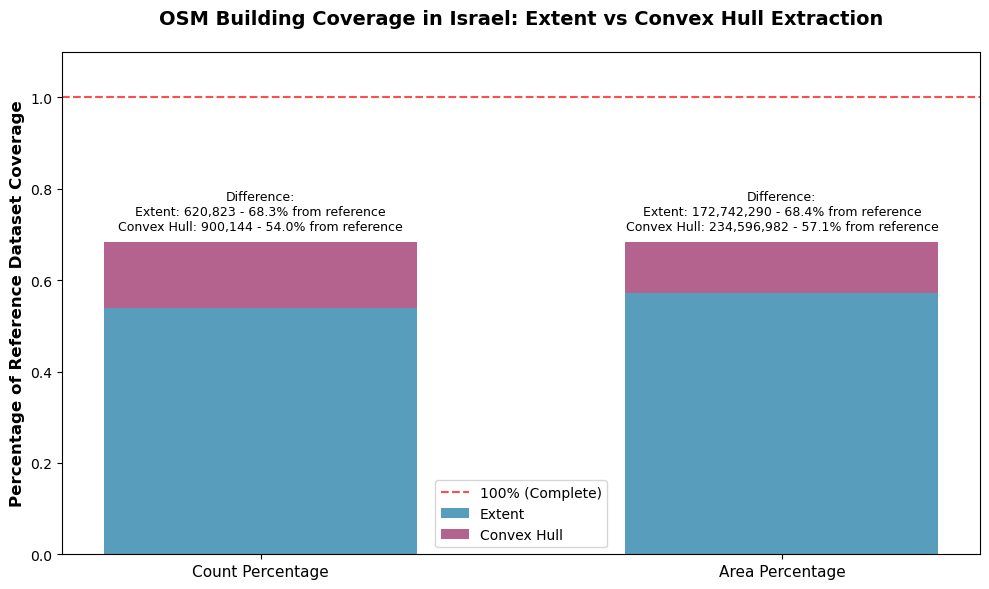

In [27]:
# Add a plot showing the differences (bar plot, with stacked bars)
fig, ax = plt.subplots(figsize=(10, 6))

# Extract percentages from difference dataframe
count_pct_bbox = difference.loc['bbox', 'count percentage']
count_pct_chull = difference.loc['chull', 'count percentage']
area_pct_bbox = difference.loc['bbox', ' area percentage']
area_pct_chull = difference.loc['chull', ' area percentage']

# Extract absolute differences
count_diff_bbox = difference.loc['bbox', 'count difference']
count_diff_chull = difference.loc['chull', 'count difference']
area_diff_bbox = difference.loc['bbox', 'area difference']
area_diff_chull = difference.loc['chull', 'area difference']

# Prepare data for stacked bars (put smaller one on top)
categories = ['Count Percentage', 'Area Percentage']
x_pos = [0, 1]

# Determine which is smaller for each metric
if count_pct_bbox < count_pct_chull:
    count_bottom_bbox = count_pct_bbox
    count_bottom_chull = 0
    count_top_chull = count_pct_chull - count_pct_bbox
else:
    count_bottom_bbox = count_pct_chull
    count_bottom_chull = 0
    count_top_chull = count_pct_bbox - count_pct_chull
    
if area_pct_bbox < area_pct_chull:
    area_bottom_bbox = area_pct_bbox
    area_bottom_chull = 0
    area_top_chull = area_pct_chull - area_pct_bbox
else:
    area_bottom_bbox = area_pct_chull
    area_bottom_chull = 0
    area_top_chull = area_pct_bbox - area_pct_chull

# Create stacked bars
bar_width = 0.6
colors_bbox = '#2E86AB'  # Bbox color
colors_chull = '#A23B72'  # Convex hull color

# Plot counts
bars1_bbox = ax.bar(x_pos[0], min(count_pct_bbox, count_pct_chull), bar_width, 
                     label='Extent', color=colors_bbox, alpha=0.8)
bars1_chull = ax.bar(x_pos[0], abs(count_pct_bbox - count_pct_chull), bar_width,
                      bottom=min(count_pct_bbox, count_pct_chull),
                      label='Convex Hull', color=colors_chull, alpha=0.8)

# Plot areas
bars2_bbox = ax.bar(x_pos[1], min(area_pct_bbox, area_pct_chull), bar_width,
                     color=colors_bbox, alpha=0.8)
bars2_chull = ax.bar(x_pos[1], abs(area_pct_bbox - area_pct_chull), bar_width,
                      bottom=min(area_pct_bbox, area_pct_chull),
                      color=colors_chull, alpha=0.8)

# Add text annotations above bars
# For counts
max_count = max(count_pct_bbox, count_pct_chull)
ax.text(x_pos[0], max_count + 0.02, 
        f'Difference:\nExtent: {int(count_diff_bbox):,} - {count_pct_bbox*100:.1f}% from reference\n'
        f'Convex Hull: {int(count_diff_chull):,} - {count_pct_chull*100:.1f}% from reference',
        ha='center', va='bottom', fontsize=9)

# For areas
max_area = max(area_pct_bbox, area_pct_chull)
ax.text(x_pos[1], max_area + 0.02,
        f'Difference:\nExtent: {int(area_diff_bbox):,} - {area_pct_bbox*100:.1f}% from reference\n'
        f'Convex Hull: {int(area_diff_chull):,} - {area_pct_chull*100:.1f}% from reference',
        ha='center', va='bottom', fontsize=9)

# Customize plot
ax.set_ylabel('Percentage of Reference Dataset Coverage', fontsize=12, weight='bold')
ax.set_title('OSM Building Coverage in Israel: Extent vs Convex Hull Extraction', 
             fontsize=14, weight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='100% (Complete)')

# Remove duplicate labels and create legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower center', fontsize=10)

plt.tight_layout()
plt.show() 

## Smaller scale analysis

### Data extraction

In [28]:
# # Upload bounds
# tlv_convex_hull = gpd.read_file(r'C:\GIS\1_Work\OSM_research\sandbox\israel data\tlv_municipality.shp')
# il_regions = gpd.read_file(r'C:\GIS\1_Work\OSM_research\sandbox\sandbox.gdb', layer='regions_israel')

# # update crs
# tlv_convex_hull = tlv_convex_hull.to_crs(epsg=4326).geometry.iloc[0].__geo_interface__ # update geometry only for post function
# il_regions = il_regions.to_crs(epsg=4326)


# # Extract more regions' geometry
# il_regions = il_regions.sort_values(by='name')
# gushd_geom = il_regions.iloc[1].geometry.__geo_interface__
# center_geom = il_regions.loc[1, 'geometry'].union(il_regions.loc[2, 'geometry']).__geo_interface__
# haifa_geom = il_regions.iloc[2].geometry.__geo_interface__
# all_north_geom = il_regions.loc[3, 'geometry'].union(il_regions.loc[4, 'geometry']).__geo_interface__
# jeru_metropolin_geom = il_regions.iloc[3].geometry.__geo_interface__

# # Extract OSM data
# # counts
# tlv_count = post_count(geom=tlv_convex_hull, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# gushd_count = post_count(geom=gushd_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# center_count = post_count(geom=center_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# haifa_count = post_count(geom=haifa_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# all_north_count = post_count(geom=all_north_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# jeru_metropolin_count = post_count(geom=jeru_metropolin_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")

# # areas
# tlv_area = post_area(geom=tlv_convex_hull, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# gushd_area = post_area(geom=gushd_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# center_area = post_area(geom=center_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# haifa_area = post_area(geom=haifa_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# all_north_area = post_area(geom=all_north_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")
# jeru_metropolin_area = post_area(geom=jeru_metropolin_geom, filter="type:way and building=*", time="2008-01-01/2026-01-01/P1M")

In [29]:
# # Save to CSV
# # counts
# tlv_count.to_csv(main_dir + r'\1) Data\3) validity\tlv_bld_counts.csv')
# gushd_count.to_csv(main_dir + r'\1) Data\3) validity\gushd_bld_counts.csv')
# center_count.to_csv(main_dir + r'\1) Data\3) validity\center_bld_counts.csv')
# haifa_count.to_csv(main_dir + r'\1) Data\3) validity\haifa_bld_counts.csv')
# all_north_count.to_csv(main_dir + r'\1) Data\3) validity\all_north_bld_counts.csv')
# jeru_metropolin_count.to_csv(main_dir + r'\1) Data\3) validity\jeru_metropolin_bld_counts.csv')

# # areas
# tlv_area.to_csv(main_dir + r'\1) Data\3) validity\tlv_bld_areas.csv')
# gushd_area.to_csv(main_dir + r'\1) Data\3) validity\gushd_bld_areas.csv')
# center_area.to_csv(main_dir + r'\1) Data\3) validity\center_bld_areas.csv')
# haifa_area.to_csv(main_dir + r'\1) Data\3) validity\haifa_bld_areas.csv')
# all_north_area.to_csv(main_dir + r'\1) Data\3) validity\all_north_bld_areas.csv')
# jeru_metropolin_area.to_csv(main_dir + r'\1) Data\3) validity\jeru_metropolin_bld_areas.csv')

In [30]:
# For quicker upload
# counts
tlv_count = pd.read_csv(main_dir + r'\1) Data\3) validity\tlv_bld_counts.csv')
gushd_count = pd.read_csv(main_dir + r'\1) Data\3) validity\gushd_bld_counts.csv')
center_count = pd.read_csv(main_dir + r'\1) Data\3) validity\center_bld_counts.csv')
haifa_count = pd.read_csv(main_dir + r'\1) Data\3) validity\haifa_bld_counts.csv')
all_north_count = pd.read_csv(main_dir + r'\1) Data\3) validity\all_north_bld_counts.csv')
jeru_metropolin_count = pd.read_csv(main_dir + r'\1) Data\3) validity\jeru_metropolin_bld_counts.csv')

# areas
tlv_area = pd.read_csv(main_dir + r'\1) Data\3) validity\tlv_bld_areas.csv')
gushd_area = pd.read_csv(main_dir + r'\1) Data\3) validity\gushd_bld_areas.csv')
center_area = pd.read_csv(main_dir + r'\1) Data\3) validity\center_bld_areas.csv')
haifa_area = pd.read_csv(main_dir + r'\1) Data\3) validity\haifa_bld_areas.csv')
all_north_area = pd.read_csv(main_dir + r'\1) Data\3) validity\all_north_bld_areas.csv')
jeru_metropolin_area = pd.read_csv(main_dir + r'\1) Data\3) validity\jeru_metropolin_bld_areas.csv')

### Metric calculation

In [31]:
# Assess feature completeness
bld_small_scale_tests = {
    'Tel Aviv' : assess_feature_completeness(tlv_count, tlv_area, return_full=True),
    'Gush Dan' : assess_feature_completeness(gushd_count, gushd_area, return_full=True),
    'Center' : assess_feature_completeness(center_count, center_area, return_full=True),
    'Jerusalem metropolin' : assess_feature_completeness(jeru_metropolin_count, jeru_metropolin_area, return_full=True),
    'Haifa' : assess_feature_completeness(haifa_count, haifa_area, return_full=True),
    'Northern Israel' : assess_feature_completeness(all_north_count, all_north_area, return_full=True)
    }

In [49]:
# Print results
status = pd.DataFrame({
    'Region' : bld_small_scale_tests.keys(),
    'Status' : [bld_small_scale_tests[x]['status'] for x in bld_small_scale_tests.keys()]
    })

print('Status per each region:')
status

Status per each region:


,Region,Status
0,Tel Aviv,incomplete
1,Gush Dan,incomplete
2,Center,incomplete
3,Jerusalem metropolin,incomplete
4,Haifa,incomplete
5,Northern Israel,incomplete


In [50]:
# Print more detailed results
status['Incompletion reason'] = [bld_small_scale_tests[x]['incompletion_reason']
                                             if bld_small_scale_tests[x]['incompletion_reason'] is not None
                                             else ''
                                             for x in status['Region']]
status['Final count (2026)'] = [bld_small_scale_tests[x]['result']['count'].iloc[-1] for x in status['Region']]
status['Final area (2026)'] = [round(bld_small_scale_tests[x]['result']['size'].iloc[-1],4) for x in status['Region']]
status['Final metric value (2026)'] = [round(bld_small_scale_tests[x]['result']['cumulative_percentage'].iloc[-1],4) for x in status['Region']]
status['Final normalized metric value (2026)'] = [round(bld_small_scale_tests[x]['result']['normalized_cum_per'].iloc[-1],4) for x in status['Region']]

print('Detailed results per each region:')
status

Detailed results per each region:


,Region,Status,Incompletion reason,Final count (2026),Final area (2026),Final metric value (2026),Final normalized metric value (2026)
0,Tel Aviv,incomplete,stable relative addition larger than threshold,26931.0,10714172.97,397.8379,0.0444
1,Gush Dan,incomplete,stable relative addition larger than threshold,75091.0,30086555.27,400.6679,0.0213
2,Center,incomplete,stable relative addition larger than threshold,248873.0,92892605.11,373.2530,0.0007
3,Jerusalem metropolin,incomplete,stable relative addition larger than threshold,58267.0,21145793.32,362.9120,0.0591
4,Haifa,incomplete,stable relative addition larger than threshold,86073.0,29871614.79,347.0498,0.0091
5,Northern Israel,incomplete,stable relative addition larger than threshold,227914.0,77052633.45,338.0777,0.0089


All the regions above failed. We can see that all normalized metric values are very low, but all regions failed due to consistent community updates.

I'll now inspect it according to Mapi's data:

In [82]:
# calculate n per each region (ArcGIS Pro tool - summarize within)
il_regions_bld22 = gpd.read_file(r'C:\GIS\1_Work\OSM_research\sandbox\sandbox.gdb', layer='regions_bld22')


In [83]:
# Arrange exported dataframe
il_regions_bld22.drop(columns=['Shape_Length', 'Shape_Area', 'geometry'], inplace=True)
il_regions_bld22.rename(columns={'sum_Area_SQUAREMETERS' : 'Cumulative area',
                                 'Polygon_Count' : 'Building count'}, inplace=True)
il_regions_bld22 = pd.DataFrame(il_regions_bld22)

In [84]:
# Sum center region to fit the extracted polygon
new_row = pd.DataFrame({
    'name': ['greater center'],
    'Cumulative area': [il_regions_bld22[il_regions_bld22['name'] == 'center']['Cumulative area'].values[0] + il_regions_bld22[il_regions_bld22['name'] == 'gush dan']['Cumulative area'].values[0]],
    'Building count': [il_regions_bld22[il_regions_bld22['name'] == 'center']['Building count'].values[0] + il_regions_bld22[il_regions_bld22['name'] == 'gush dan']['Building count'].values[0]]
})


il_regions_bld22 = pd.concat([il_regions_bld22, new_row], ignore_index=True)

In [85]:
# Emit extra row
il_regions_bld22 = il_regions_bld22[il_regions_bld22['name'] != 'center'].copy()
il_regions_bld22.rename(columns={'name' : 'Region'}, inplace=True)
il_regions_bld22['Region'][il_regions_bld22['Region'] == 'greater center'] = 'center'

C:\Users\eliya\AppData\Local\Temp\ipykernel_21880\2370331819.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  il_regions_bld22['Region'][il_regions_bld22['Region'] == 'greater center'] = 'center'
C:\Users\eliya\AppData\Local\Temp\ipykerne

In [86]:
# Calculate metric
il_regions_bld22['Metric'] = il_regions_bld22['Cumulative area'] / il_regions_bld22['Building count']

In [91]:
# Display results
il_regions_bld22

,Region,Cumulative area,Building count,Metric
0,gush dan,2.935633e+07,99517,294.988087
2,tel aviv,1.036837e+07,33373,310.681420
3,haifa,5.993045e+07,186734,320.940188
4,north,1.000476e+08,372646,268.479010
5,jerusalem,2.584545e+07,96350,268.245460
6,center,1.262584e+08,427489,295.348906


### Comparisson

In [90]:
status

,Region,Status,Incompletion reason,Final count (2026),Final area (2026),Final metric value (2026),Final normalized metric value (2026)
0,Tel Aviv,incomplete,stable relative addition larger than threshold,26931.0,10714172.97,397.8379,0.0444
1,Gush Dan,incomplete,stable relative addition larger than threshold,75091.0,30086555.27,400.6679,0.0213
2,Center,incomplete,stable relative addition larger than threshold,248873.0,92892605.11,373.2530,0.0007
3,Jerusalem metropolin,incomplete,stable relative addition larger than threshold,58267.0,21145793.32,362.9120,0.0591
4,Haifa,incomplete,stable relative addition larger than threshold,86073.0,29871614.79,347.0498,0.0091
5,Northern Israel,incomplete,stable relative addition larger than threshold,227914.0,77052633.45,338.0777,0.0089


In [92]:
# Create mapping between region names
region_mapping = {
    'Tel Aviv': 'tel aviv',
    'Gush Dan': 'gush dan',
    'Center': 'center',
    'Jerusalem metropolin': 'jerusalem',
    'Haifa': 'haifa',
    'Northern Israel': 'north'
}

# Create comparison dataframe for each region
# Map il_regions_bld22 to use status region names for proper joining
il_regions_mapped = il_regions_bld22.copy()
il_regions_mapped['Region_mapped'] = il_regions_mapped['Region'].apply(lambda x: [k for k, v in region_mapping.items() if v == x][0] if x in region_mapping.values() else x)

# Merge status and il_regions_bld22 to compare OSM vs BLD22 data
comparison_df = status.set_index('Region').join(il_regions_mapped.set_index('Region_mapped'))

# Calculate differences
difference_small_scale = pd.DataFrame()
for region in comparison_df.index:
    if pd.notna(comparison_df.loc[region, 'Building count']):
        difference_small_scale.loc[region, 'count difference'] = comparison_df.loc[region, 'Building count'] - comparison_df.loc[region, 'Final count (2026)']
        difference_small_scale.loc[region, 'count percentage'] = comparison_df.loc[region, 'Final count (2026)'] / comparison_df.loc[region, 'Building count']
        difference_small_scale.loc[region, 'area difference'] = comparison_df.loc[region, 'Cumulative area'] - comparison_df.loc[region, 'Final area (2026)']
        difference_small_scale.loc[region, 'area percentage'] = comparison_df.loc[region, 'Final area (2026)'] / comparison_df.loc[region, 'Cumulative area']
        difference_small_scale.loc[region, 'metric difference'] = comparison_df.loc[region, 'Metric'] - comparison_df.loc[region, 'Final metric value (2026)']
        difference_small_scale.loc[region, 'normalized metric value'] = comparison_df.loc[region, 'Final normalized metric value (2026)']

difference_small_scale

,count difference,count percentage,area difference,area percentage,metric difference,normalized metric value
Tel Aviv,6442.0,0.806970,-3.458020e+05,1.033352,-87.156480,0.0444
Gush Dan,24426.0,0.754554,-7.302258e+05,1.024875,-105.679813,0.0213
Center,178616.0,0.582174,3.336580e+07,0.735734,-77.904094,0.0007
Jerusalem metropolin,38083.0,0.604743,4.699657e+06,0.818163,-94.666540,0.0591
Haifa,100661.0,0.460939,3.005883e+07,0.498438,-26.109612,0.0091
Northern Israel,144732.0,0.611610,2.299500e+07,0.770160,-69.598690,0.0089


Now, we can see above that all areas had a consistent relative addition that failed the test -> being true to the actual percentages (with Israel's center behaving as we would expect - having larger filling percetnages for smaller areas, and the north being the oposite, as Haifa is less complete than the entire area, maybe poniting to rural areas creating a bias toward completeness when averaging with cities).

While 2 areas have larger building area calculated in OSM for some reason (perhaps indesripancies), the metric difference shows us that in each of them the average added size is much larger than the actual average size in 2022, being at least 26 sqaure meters more, sometimes even 105 for very populated areas.

**However, it does allow a notion - maybe we need to take an interval threshold from the actual average size in some areas as a confidence interval to show how far we are from it or change our $\gamma$ threshold, enabling a validity positive test (according to local characteristics or cultural building characteristics).**

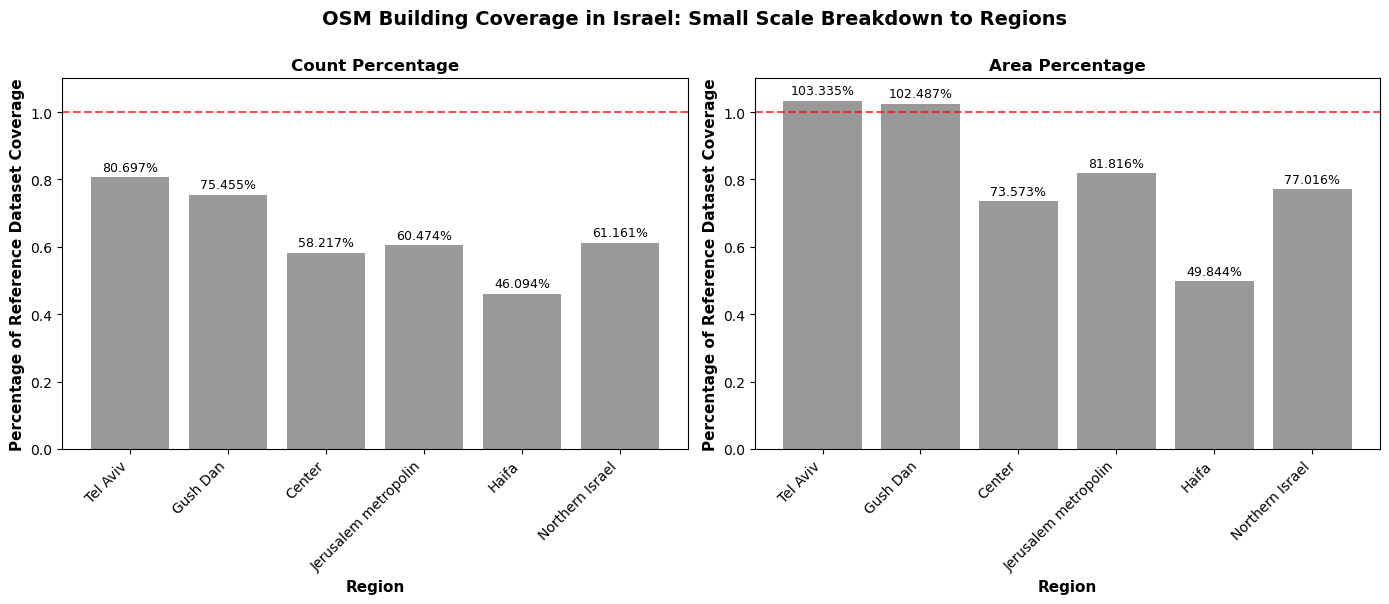

In [95]:
# Create facet plot showing count and area percentages by region
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Get regions in current order
regions = difference_small_scale.index.tolist()
x_pos = range(len(regions))

# Plot 1: Count Percentage
count_pcts = difference_small_scale['count percentage'].values
bars1 = ax1.bar(x_pos, count_pcts, color='gray', alpha=0.8)

# Add percentage annotations on count bars
for i, (bar, pct) in enumerate(zip(bars1, count_pcts)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{pct*100:.3f}%', ha='center', va='bottom', fontsize=9)

ax1.set_ylabel('Percentage of Reference Dataset Coverage', fontsize=11, weight='bold')
ax1.set_xlabel('Region', fontsize=11, weight='bold')
ax1.set_title('Count Percentage', fontsize=12, weight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(regions, rotation=45, ha='right', fontsize=10)
ax1.set_ylim(0, 1.1)
ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Plot 2: Area Percentage
area_pcts = difference_small_scale['area percentage'].values
bars2 = ax2.bar(x_pos, area_pcts, color='gray', alpha=0.8)

# Add percentage annotations on area bars
for i, (bar, pct) in enumerate(zip(bars2, area_pcts)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{pct*100:.3f}%', ha='center', va='bottom', fontsize=9)

ax2.set_ylabel('Percentage of Reference Dataset Coverage', fontsize=11, weight='bold')
ax2.set_xlabel('Region', fontsize=11, weight='bold')
ax2.set_title('Area Percentage', fontsize=12, weight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(regions, rotation=45, ha='right', fontsize=10)
ax2.set_ylim(0, 1.1)
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Overall title
fig.suptitle('OSM Building Coverage in Israel: Small Scale Breakdown to Regions',
            fontsize=14, weight='bold', y=1.00)

plt.tight_layout()
plt.show()